In [35]:
CIBUSmod_dir = '..'
output_dir = '../../MFF-scenarios/output'
scn_name = 'MFF'

In [36]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),CIBUSmod_dir))

import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
# Create session
session = cm.Session(
    name = scn_name,
    data_path = os.path.join(CIBUSmod_dir,'data'),
    data_path_output = output_dir
)

In [101]:
c_area = session.get_attr('C','area',{'crop':'land_use'}).loc[:,'cropland']

Text(0.5, 1.0, 'Crop residues')

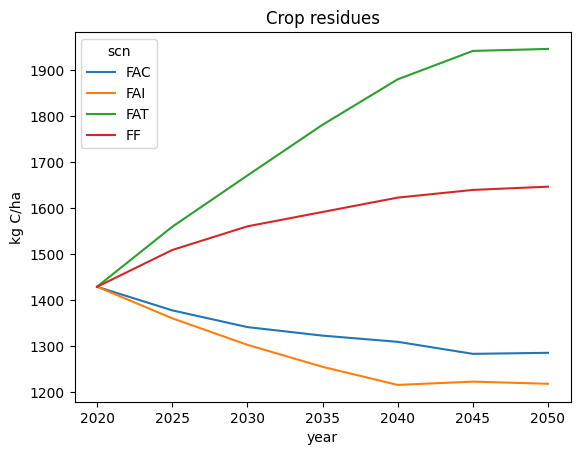

In [102]:
d1 = session.get_attr('C','fertiliser.crop_residues_C',
                 {'crop':'land_use','region':None,'prod_system':None,'residue':None}, interpolate=False).loc[:,'cropland']
ax = d1.sum(axis=1).div(c_area).unstack('scn').plot(ylabel='kg C/ha')
ax.set_title('Crop residues')

Text(0.5, 1.0, 'Cover crop residues')

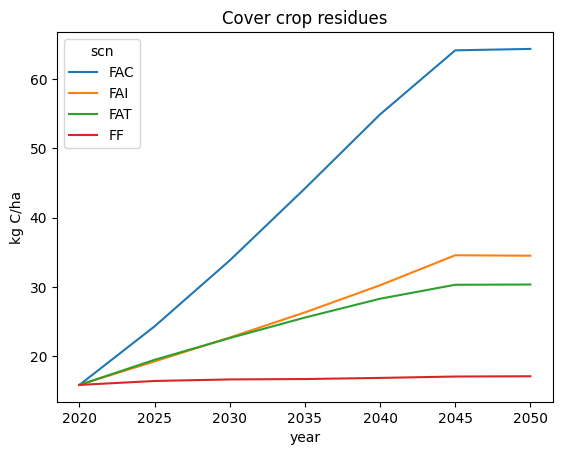

In [104]:
d2 = session.get_attr('C','fertiliser.cover_crop_residues_C',
                 {'crop':'land_use','region':None,'prod_system':None,'residue':None}, interpolate=False).loc[:,'cropland']
ax = d2.sum(axis=1).div(c_area).unstack('scn').plot(ylabel='kg C/ha')
ax.set_title('Cover crop residues')

Text(0.5, 1.0, 'Manure')

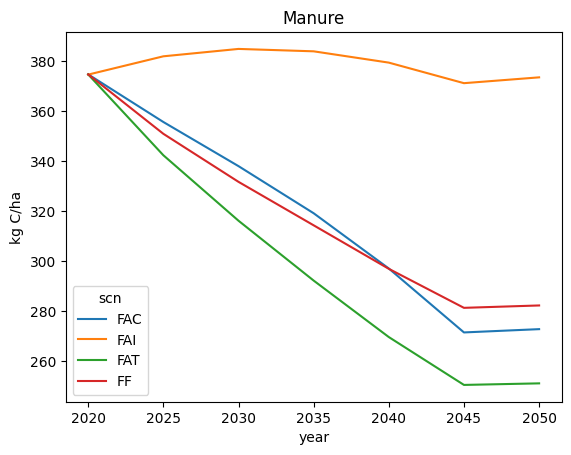

In [106]:
d3 = session.get_attr('C','fertiliser.manure_C',
                 {'crop':'land_use','region':None,'prod_system':None}, interpolate=False).loc[:,'cropland']
ax = d3.sum(axis=1).div(c_area).unstack('scn').plot(ylabel='kg C/ha')
ax.set_title('Manure')

Text(0.5, 1.0, 'Other org. fertiliser')

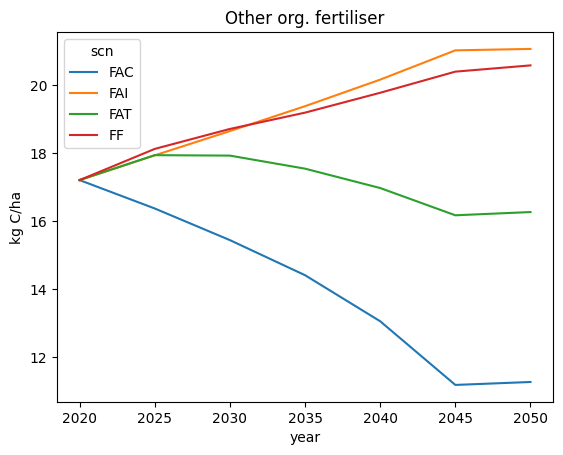

In [107]:
d4 = session.get_attr('C','fertiliser.organic_C',
                 {'crop':'land_use','region':None,'prod_system':None}, interpolate=False).loc[:,'cropland']
ax = d4.sum(axis=1).div(c_area).unstack('scn').plot(ylabel='kg C/ha')
ax.set_title('Other org. fertiliser')

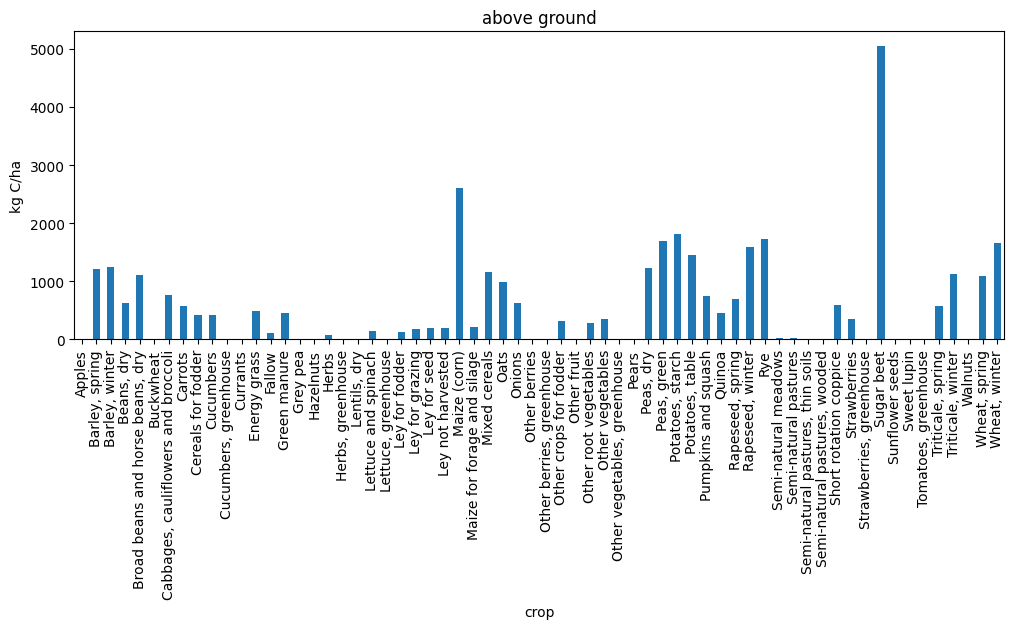

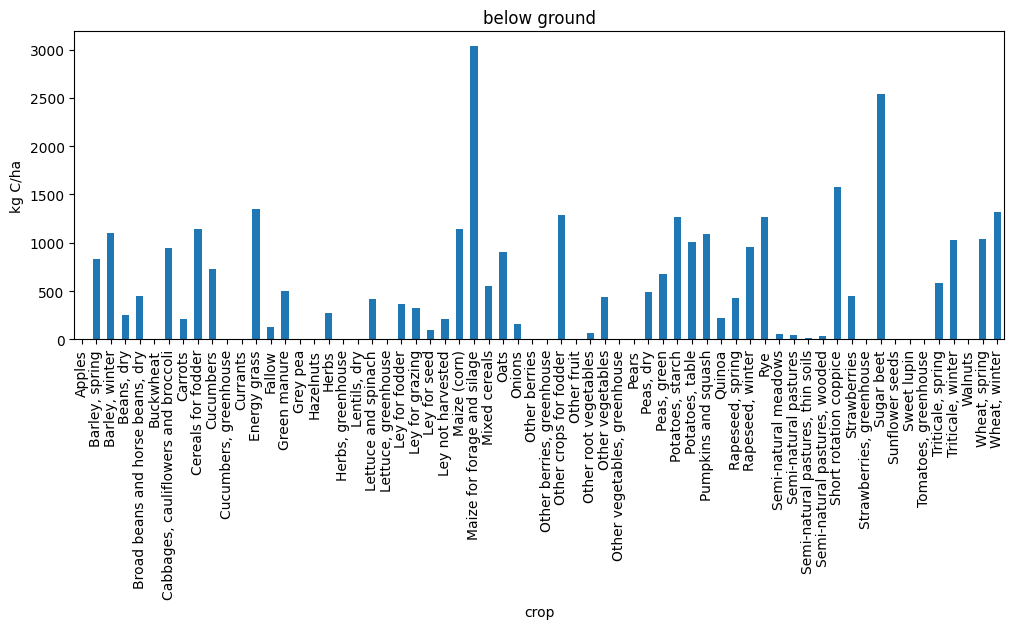

In [108]:
# Check crop residue C per crop

for r in ['above ground','below ground']:
    ax = (session.get_attr('C','fertiliser.crop_residues_C',['residue','crop']).loc[:,r] / session.get_attr('C','area',['crop'])).loc[('FAI','2020')].plot.bar(figsize=(12,4),ylabel='kg C/ha')
    ax.set_title(r)
    plt.show()

In [ ]:
# Create soil model input csv files
c_area = (
    session.get_attr('C','area', {'crop':'land_use','region':None,'prod_system':None})
    .xs('cropland', level='land_use', axis=1)
    .stack('prod_system').stack('region')
)
df = (
    session.get_attr('C','fertiliser.crop_residues_C',{'prod_system':None,'region':None,'crop':['land_use',None],'residue':None})
    .xs('cropland', level='land_use', axis=1)
    .stack('prod_system').stack('region')
    .fillna(0)
    .div(c_area, axis=0)
    .stack()
    .stack()
)
df.to_csv('crop_residues_C.csv')

df = (
    session.get_attr('C','fertiliser.cover_crop_residues_C',{'prod_system':None,'region':None,'crop':['land_use'],'residue':None})
    .xs('cropland', level='land_use', axis=1)
    .stack('prod_system').stack('region')
    .fillna(0)
    .div(c_area, axis=0)
    .stack()
)
df.to_csv('cover_crop_residues_C.csv')

df = (
    session.get_attr('C','fertiliser.manure_C',{'prod_system':None,'region':None,'crop':['land_use']})
    .xs('cropland', level='land_use', axis=1)
    .stack('prod_system').stack('region')
    .fillna(0)
    .div(c_area)
)
df.to_csv('manure_C.csv')

df = (
    session.get_attr('C','fertiliser.organic_C',{'prod_system':None,'region':None,'crop':['land_use']})
    .xs('cropland', level='land_use', axis=1)
    .stack('prod_system').stack('region')
    .fillna(0)
    .div(c_area, axis=0)
)
df.to_csv('other_organic_fertiliser_C.csv')